<a href="https://colab.research.google.com/github/yair040/AI_Course_Ramat_Gan-/blob/main/Lesson41_Transfer_Learning%5CDiabetic_Retinopathy_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 Diabetic Retinopathy Risk Assessment System
**Author: Yair Levi**

---

## Project Overview
Diabetic Retinopathy (DR) is one of the leading causes of blindness worldwide. This notebook implements an end-to-end deep learning pipeline that classifies retinal fundus images into **5 severity levels** of diabetic retinopathy using **Transfer Learning** with a ResNet-50 backbone.

| Class | Label | Description |
|-------|-------|-------------|
| 0 | No DR | No signs of diabetic retinopathy |
| 1 | Mild | Microaneurysms only |
| 2 | Moderate | More than just microaneurysms |
| 3 | Severe | Extensive hemorrhages |
| 4 | Proliferative DR | Abnormal new blood vessel growth |

### Pipeline Overview
1. ⚙️ Setup & configuration
2. 📂 Mount Google Drive & load dataset
3. 🖼️ Visual sample display (1 image per class)
4. ⚖️ Balance preprocessing (downsample / augment)
5. 📐 Resolution preprocessing (resize to 224×224)
6. 🔀 Dataset split & DataLoaders
7. 🧠 Model setup (ResNet-50 + custom head)
8. 🧪 Experiment 1: Zero-shot evaluation
9. 🎯 Experiment 2: Fine-tune last FC layer
10. 🚀 Experiment 3: Deep layer fine-tuning
11. 📊 Results comparison across experiments

---
## Section 1: Setup & Imports

This section installs any required packages not available by default in Colab, imports all necessary libraries, and defines all **user-configurable parameters** in one place. You can change the parameters here to control model behavior, training duration, and preprocessing choices.

### Key user parameters:
- `USE_BATCH_NORM`: Toggle batch normalization in the custom classifier head on/off
- `LEARNING_RATE`: Adam optimizer learning rate
- `BATCH_SIZE`: Mini-batch size for training (reduce if you hit GPU OOM errors)
- `NUM_EPOCHS`: Training epochs per experiment
- `UNFREEZE_LAYERS`: Which ResNet-50 blocks to unfreeze in Experiment 3

In [5]:
# ── Install / upgrade packages if needed ──────────────────────────────────────
# Colab already has torch, torchvision, PIL, pandas, numpy, matplotlib, sklearn.
# We install seaborn for nicer confusion matrix plots.
!pip install seaborn --quiet

# ── Standard library imports ──────────────────────────────────────────────────
import os
import time
import copy
import shutil
import random
from pathlib import Path

# ── Data handling ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Image processing ──────────────────────────────────────────────────────────
from PIL import Image, ImageFilter, ImageEnhance

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
from torchvision import transforms, models

# ── Metrics ───────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)

# ══════════════════════════════════════════════════════════════════════════════
#  USER-CONFIGURABLE PARAMETERS  (edit these to control the experiment)
# ══════════════════════════════════════════════════════════════════════════════

# -- Batch normalization toggle ------------------------------------------------
USE_BATCH_NORM = True        # True → add BatchNorm layer in custom head; False → skip it

# -- Training hyper-parameters -------------------------------------------------
LEARNING_RATE   = 1e-4       # Adam optimizer learning rate
LR_EXP3         = 1e-5       # Lower LR for Experiment 3 (deeper unfreeze)
BATCH_SIZE      = 32         # Reduce to 16 if you hit CUDA out-of-memory
NUM_EPOCHS      = 10         # Epochs per training experiment
RANDOM_SEED     = 42         # For reproducibility

# -- Dataset settings ----------------------------------------------------------
TARGET_PER_CLASS = 1000      # Target images per class after balancing
IMG_SIZE         = 224       # ResNet-50 requires 224×224 input
TEST_SPLIT       = 0.20      # 20% test, 80% train

# -- Transfer learning settings ------------------------------------------------
# Layers to UNFREEZE in Experiment 3 (in addition to the FC head).
# ResNet-50 has: layer1, layer2, layer3, layer4
UNFREEZE_LAYERS = ['layer4', 'fc']

# -- Google Drive paths --------------------------------------------------------
DRIVE_ROOT   = '/content/drive/MyDrive/Diabetic_Retinopathy'
IMAGES_DIR   = os.path.join(DRIVE_ROOT, 'images')
LABELS_CSV   = os.path.join(DRIVE_ROOT, 'labels.csv')
MODELS_DIR   = os.path.join(DRIVE_ROOT, 'models')
PROC_DIR     = os.path.join(DRIVE_ROOT, 'preprocessed')  # cache for processed images

# -- Class metadata ------------------------------------------------------------
CLASS_NAMES = {
    0: 'No DR',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe',
    4: 'Proliferative DR'
}
NUM_CLASSES = 5

# ── Reproducibility ───────────────────────────────────────────────────────────
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# ── Device selection ──────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

print(f'\n📋 Configuration Summary:')
print(f'   Batch normalization : {USE_BATCH_NORM}')
print(f'   Learning rate (Exp2): {LEARNING_RATE}')
print(f'   Learning rate (Exp3): {LR_EXP3}')
print(f'   Batch size          : {BATCH_SIZE}')
print(f'   Epochs per run      : {NUM_EPOCHS}')
print(f'   Target images/class : {TARGET_PER_CLASS}')
print(f'   Unfreeze layers     : {UNFREEZE_LAYERS}')

✅ Using device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB

📋 Configuration Summary:
   Batch normalization : True
   Learning rate (Exp2): 0.0001
   Learning rate (Exp3): 1e-05
   Batch size          : 32
   Epochs per run      : 10
   Target images/class : 1000
   Unfreeze layers     : ['layer4', 'fc']


---
## Section 2: Mount Google Drive

We mount Google Drive to access the dataset and to save trained models. The dataset is expected at:
- **Images**: `MyDrive/Diabetic_Retinopathy/images/<image_name>.png`
- **Labels**: `MyDrive/Diabetic_Retinopathy/labels.csv`

After mounting, we verify that the paths exist and display the number of images found.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
from google.colab import drive

print('🔗 Mounting Google Drive...')
drive.mount('/content/drive')

# ── Verify dataset paths ──────────────────────────────────────────────────────
assert os.path.isdir(IMAGES_DIR), (
    f'❌ Images directory not found: {IMAGES_DIR}\n'
    f'   Please check your Google Drive folder structure.'
)
assert os.path.isfile(LABELS_CSV), (
    f'❌ Labels file not found: {LABELS_CSV}\n'
    f'   Please ensure labels.csv is in {DRIVE_ROOT}'
)

# ── Create output directories ─────────────────────────────────────────────────
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PROC_DIR, exist_ok=True)

# ── Count available images ────────────────────────────────────────────────────
all_images = [f for f in os.listdir(IMAGES_DIR) if f.endswith('.png')]
print(f'\n✅ Google Drive mounted successfully.')
print(f'   Images directory : {IMAGES_DIR}')
print(f'   Total .png files : {len(all_images)}')
print(f'   Labels CSV       : {LABELS_CSV}')
print(f'   Models will save to: {MODELS_DIR}')

🔗 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ Google Drive mounted successfully.
   Images directory : /content/drive/MyDrive/Diabetic_Retinopathy/images
   Total .png files : 3662
   Labels CSV       : /content/drive/MyDrive/Diabetic_Retinopathy/labels.csv
   Models will save to: /content/drive/MyDrive/Diabetic_Retinopathy/models


---
## Section 3: Load Labels & Explore Dataset

We load `labels.csv` into a Pandas DataFrame and perform an initial exploration:
- Confirm the expected columns (`id_code`, `diagnosis`) exist
- Display the class distribution (count per severity level)
- Verify that every image referenced in the CSV actually exists on disk

This step is essential before preprocessing to understand the imbalance problem.

📋 Labels CSV loaded.
   Shape: (3662, 2)
   Columns: ['id_code', 'diagnosis']



,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


✅ All 3662 images found on disk.

📊 Class Distribution (Original Dataset):
---------------------------------------------
  Class 0 (             No DR):  1805  ████████████████████████████████████
  Class 1 (              Mild):   370  ███████
  Class 2 (          Moderate):   999  ███████████████████
  Class 3 (            Severe):   193  ███
  Class 4 (  Proliferative DR):   295  █████
---------------------------------------------
  Total images: 3662


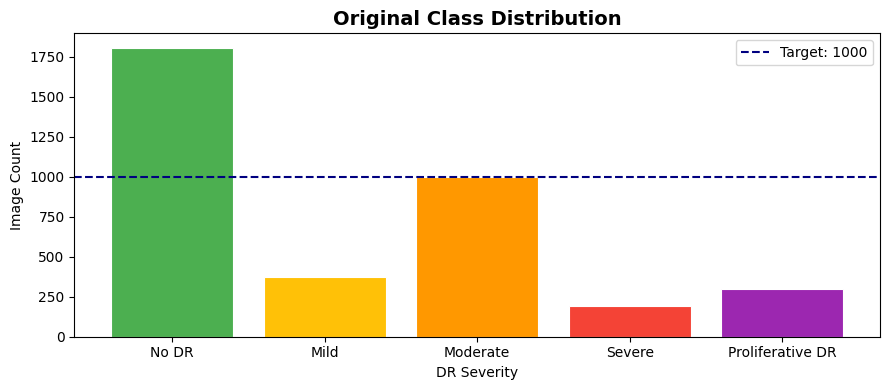

In [7]:
# ── Load labels ───────────────────────────────────────────────────────────────
df = pd.read_csv(LABELS_CSV)
print('📋 Labels CSV loaded.')
print(f'   Shape: {df.shape}')
print(f'   Columns: {list(df.columns)}')
print()
display(df.head(5))

# ── Validate expected columns ─────────────────────────────────────────────────
assert 'id_code' in df.columns and 'diagnosis' in df.columns, \
    '❌ Expected columns id_code and diagnosis not found in labels.csv'

# ── Check image files exist on disk ───────────────────────────────────────────
df['img_path'] = df['id_code'].apply(
    lambda x: os.path.join(IMAGES_DIR, x + '.png')
)
df['exists'] = df['img_path'].apply(os.path.isfile)
missing = df[~df['exists']]
if len(missing) > 0:
    print(f'⚠️  Warning: {len(missing)} images referenced in CSV not found on disk.')
    print(missing[['id_code']].head(10))
else:
    print(f'✅ All {len(df)} images found on disk.')

df = df[df['exists']].reset_index(drop=True)  # Keep only existing images

# ── Class distribution ────────────────────────────────────────────────────────
print('\n📊 Class Distribution (Original Dataset):')
print('-' * 45)
dist = df['diagnosis'].value_counts().sort_index()
for cls_id, count in dist.items():
    bar = '█' * (count // 50)
    label = CLASS_NAMES[cls_id]
    print(f'  Class {cls_id} ({label:>18}): {count:>5}  {bar}')
print('-' * 45)
print(f'  Total images: {len(df)}')

# ── Bar chart of class distribution ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#4CAF50', '#FFC107', '#FF9800', '#F44336', '#9C27B0']
ax.bar([CLASS_NAMES[i] for i in range(5)],
       [dist.get(i, 0) for i in range(5)],
       color=colors, edgecolor='white', linewidth=0.8)
ax.axhline(TARGET_PER_CLASS, color='navy', linestyle='--',
            linewidth=1.5, label=f'Target: {TARGET_PER_CLASS}')
ax.set_title('Original Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Image Count')
ax.set_xlabel('DR Severity')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 4: Visual Sample Display

Before any preprocessing, we display **one representative image from each of the 5 classes** side by side. This allows you to visually compare what each severity level looks like, helps verify that the images loaded correctly, and gives clinical context for what the model is trying to distinguish.

Images are displayed at their original resolution with the class label and diagnosis shown below each.

🖼️  Displaying one sample image per class...


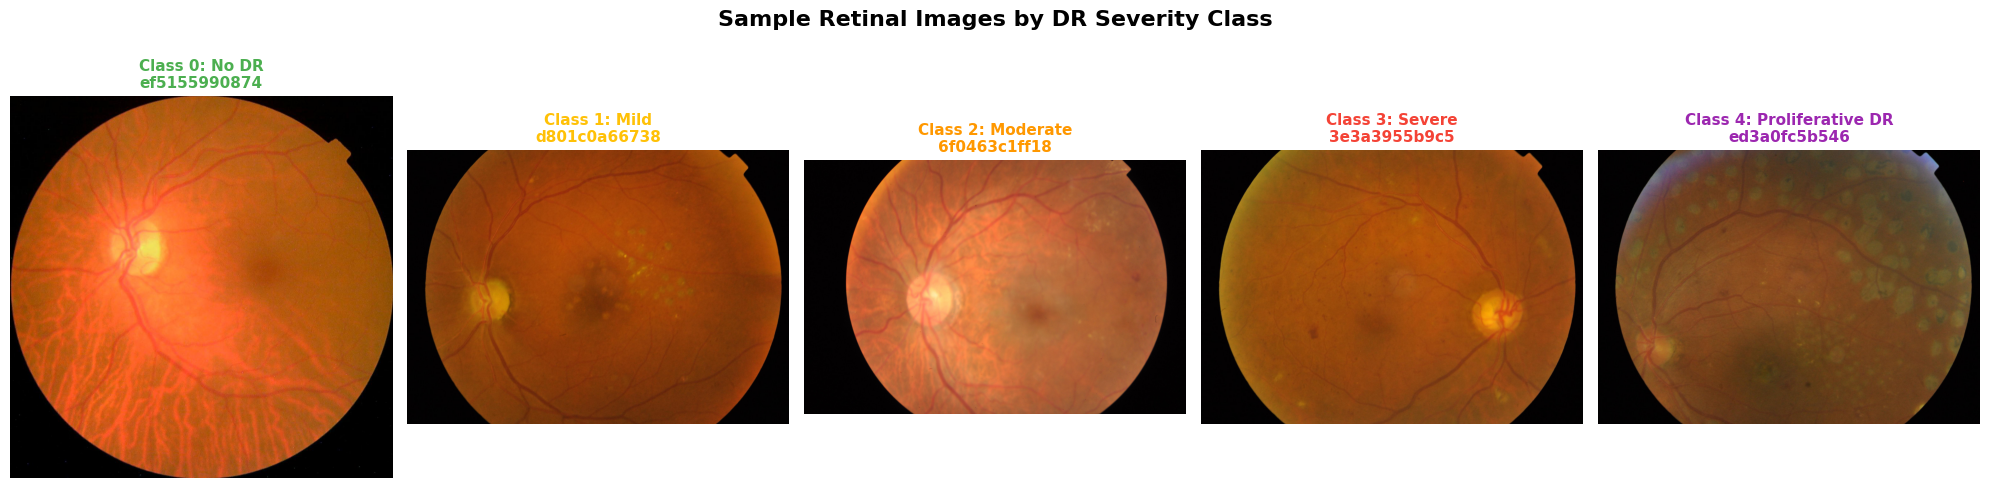

✅ Sample display complete.


In [8]:
print('🖼️  Displaying one sample image per class...')

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(20, 5))
fig.suptitle('Sample Retinal Images by DR Severity Class',
             fontsize=16, fontweight='bold', y=1.02)

severity_colors = ['#4CAF50', '#FFC107', '#FF9800', '#F44336', '#9C27B0']

for cls_id in range(NUM_CLASSES):
    # Pick one random sample from this class
    samples = df[df['diagnosis'] == cls_id]
    if len(samples) == 0:
        axes[cls_id].axis('off')
        axes[cls_id].set_title(f'Class {cls_id}\nNo samples', fontsize=11)
        continue

    row = samples.sample(1, random_state=RANDOM_SEED).iloc[0]
    img = Image.open(row['img_path']).convert('RGB')

    axes[cls_id].imshow(img)
    axes[cls_id].axis('off')
    axes[cls_id].set_title(
        f'Class {cls_id}: {CLASS_NAMES[cls_id]}\n{row["id_code"]}',
        fontsize=11, fontweight='bold',
        color=severity_colors[cls_id]
    )
    # Colored border to indicate severity
    for spine in axes[cls_id].spines.values():
        spine.set_visible(True)
        spine.set_color(severity_colors[cls_id])
        spine.set_linewidth(3)

plt.tight_layout()
plt.show()
print('✅ Sample display complete.')

---
## Section 5: Balance Preprocessing

The dataset is **heavily imbalanced** — classes range from 194 to 1,806 images. Training on an imbalanced dataset causes the model to be biased toward majority classes. We fix this by:

1. **Downsampling** over-represented classes (0 and 4): Randomly select `TARGET_PER_CLASS` images.
2. **Augmenting** under-represented classes (1 and 3): Generate synthetic images using random transformations until each class has `TARGET_PER_CLASS` images.
3. **Keeping** class 2 as-is (it already has ~1,000 images).

**Why do this BEFORE resolution preprocessing?**
Balancing first reduces the total number of images that need to be resized. This is faster and uses less memory, since we avoid resizing images that we would later discard.

**Augmentation transforms used:**
- Horizontal & vertical flips
- Random rotation (±15°)
- Brightness/contrast jitter (±10%)
- Optional mild Gaussian blur

Elapsed time is measured and reported.

In [9]:
# ── Augmentation helper ───────────────────────────────────────────────────────
def augment_image(img: Image.Image) -> Image.Image:
    """Apply random augmentation transforms to a PIL image."""
    # Horizontal flip
    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)
    # Vertical flip
    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_TOP_BOTTOM)
    # Random rotation ±15°
    angle = random.uniform(-15, 15)
    img = img.rotate(angle, resample=Image.BICUBIC, expand=False)
    # Brightness jitter ±10%
    factor = random.uniform(0.90, 1.10)
    img = ImageEnhance.Brightness(img).enhance(factor)
    # Contrast jitter ±10%
    factor = random.uniform(0.90, 1.10)
    img = ImageEnhance.Contrast(img).enhance(factor)
    # Mild Gaussian blur (30% chance)
    if random.random() < 0.30:
        img = img.filter(ImageFilter.GaussianBlur(radius=0.8))
    return img


# ── Balance preprocessing (operates on DataFrame, no disk writes yet) ─────────
print('⚖️  Starting Balance Preprocessing...')
t_balance_start = time.time()

balanced_records = []   # List of (img_path, label, is_augmented, aug_index)

for cls_id in range(NUM_CLASSES):
    cls_df = df[df['diagnosis'] == cls_id].reset_index(drop=True)
    n_orig = len(cls_df)
    label_name = CLASS_NAMES[cls_id]

    if n_orig >= TARGET_PER_CLASS:
        # ── Downsample ─────────────────────────────────────────────────────────
        selected = cls_df.sample(TARGET_PER_CLASS,
                                  random_state=RANDOM_SEED).reset_index(drop=True)
        for _, row in selected.iterrows():
            balanced_records.append({
                'id_code': row['id_code'],
                'img_path': row['img_path'],
                'diagnosis': cls_id,
                'is_augmented': False,
                'aug_index': 0
            })
        print(f'  Class {cls_id} ({label_name:>18}): {n_orig} → {TARGET_PER_CLASS}  (downsampled)')

    else:
        # ── Keep all originals ─────────────────────────────────────────────────
        for _, row in cls_df.iterrows():
            balanced_records.append({
                'id_code': row['id_code'],
                'img_path': row['img_path'],
                'diagnosis': cls_id,
                'is_augmented': False,
                'aug_index': 0
            })
        # ── Augment to reach TARGET_PER_CLASS ──────────────────────────────────
        n_needed = TARGET_PER_CLASS - n_orig
        aug_pool = cls_df['img_path'].tolist()
        for aug_idx in range(n_needed):
            src_path = aug_pool[aug_idx % len(aug_pool)]
            src_id   = cls_df.iloc[aug_idx % len(aug_pool)]['id_code']
            balanced_records.append({
                'id_code': src_id,
                'img_path': src_path,
                'diagnosis': cls_id,
                'is_augmented': True,
                'aug_index': aug_idx + 1
            })
        print(f'  Class {cls_id} ({label_name:>18}): {n_orig} → {TARGET_PER_CLASS}  '
              f'(+{n_needed} augmented)')

balanced_df = pd.DataFrame(balanced_records)

t_balance_end = time.time()
t_balance = t_balance_end - t_balance_start

print(f'\n✅ Balance preprocessing complete.')
print(f'   Total balanced records : {len(balanced_df)}')
print(f'   ⏱️  Elapsed time        : {t_balance:.2f} seconds')
print()

# ── Verify balance ────────────────────────────────────────────────────────────
print('📊 Balanced class counts:')
for cls_id in range(NUM_CLASSES):
    cnt = (balanced_df['diagnosis'] == cls_id).sum()
    print(f'   Class {cls_id} ({CLASS_NAMES[cls_id]:>18}): {cnt}')

⚖️  Starting Balance Preprocessing...
  Class 0 (             No DR): 1805 → 1000  (downsampled)
  Class 1 (              Mild): 370 → 1000  (+630 augmented)
  Class 2 (          Moderate): 999 → 1000  (+1 augmented)
  Class 3 (            Severe): 193 → 1000  (+807 augmented)
  Class 4 (  Proliferative DR): 295 → 1000  (+705 augmented)

✅ Balance preprocessing complete.
   Total balanced records : 5000
   ⏱️  Elapsed time        : 0.19 seconds

📊 Balanced class counts:
   Class 0 (             No DR): 1000
   Class 1 (              Mild): 1000
   Class 2 (          Moderate): 1000
   Class 3 (            Severe): 1000
   Class 4 (  Proliferative DR): 1000


---
## Section 6: Resolution Preprocessing

ResNet-50 requires input images of exactly **224×224 pixels**. In this section we resize all images in the balanced dataset to this target size.

**Why AFTER balancing?**
We now have a well-defined, fixed-size dataset (~5,000 images). Resizing at this stage means:
- No redundant resizes of images that were discarded during downsampling
- Consistent, predictable memory footprint going into training

**Resampling method:** Lanczos (high quality, minimal aliasing)

Processed images are saved to a local Colab cache directory for fast DataLoader access during training. Elapsed time is measured and displayed.

**Normalization** (mean and std from ImageNet) is applied later in the DataLoader transforms, not at this stage, so the saved files remain as regular RGB images.

In [10]:
import io

# ── Local cache directory (faster I/O than Google Drive during training) ───────
LOCAL_CACHE = '/content/dr_cache'
os.makedirs(LOCAL_CACHE, exist_ok=True)

print(f'📐 Starting Resolution Preprocessing (target: {IMG_SIZE}×{IMG_SIZE})...')
print(f'   Cache location: {LOCAL_CACHE}')
print(f'   Total images to process: {len(balanced_df)}')
print()

t_resize_start = time.time()

processed_paths = []   # Parallel list of saved file paths
n_processed = 0
n_total = len(balanced_df)

for i, row in balanced_df.iterrows():
    # Build a unique filename for this record
    aug_suffix = f'_aug{row["aug_index"]}' if row['is_augmented'] else ''
    fname = f"{row['id_code']}{aug_suffix}.png"
    out_path = os.path.join(LOCAL_CACHE, fname)

    if not os.path.isfile(out_path):  # Skip if already cached
        img = Image.open(row['img_path']).convert('RGB')

        # Apply augmentation for augmented records BEFORE resizing
        if row['is_augmented']:
            img = augment_image(img)

        # Resize to 224×224 with high-quality Lanczos filter
        img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
        img.save(out_path, format='PNG')

    processed_paths.append(out_path)
    n_processed += 1

    # Progress update every 500 images
    if n_processed % 500 == 0 or n_processed == n_total:
        pct = 100 * n_processed / n_total
        elapsed = time.time() - t_resize_start
        eta = (elapsed / n_processed) * (n_total - n_processed)
        print(f'   [{n_processed:>5}/{n_total}]  {pct:5.1f}%  '
              f'Elapsed: {elapsed:6.1f}s  ETA: {eta:6.1f}s')

t_resize_end = time.time()
t_resize = t_resize_end - t_resize_start

# ── Attach processed paths to balanced_df ─────────────────────────────────────
balanced_df = balanced_df.copy()
balanced_df['proc_path'] = processed_paths

print(f'\n✅ Resolution preprocessing complete.')
print(f'   Images processed : {len(processed_paths)}')
print(f'   Cache size       : {sum(os.path.getsize(p) for p in processed_paths)/1e6:.1f} MB')
print(f'   ⏱️  Elapsed time  : {t_resize:.2f} seconds')

# ── Timing summary so far ──────────────────────────────────────────────────────
print(f'\n📊 Preprocessing Timing Summary:')
print(f'   Balance preprocessing  : {t_balance:.2f}s')
print(f'   Resolution preprocessing: {t_resize:.2f}s')
print(f'   Total preprocessing    : {t_balance + t_resize:.2f}s')

📐 Starting Resolution Preprocessing (target: 224×224)...
   Cache location: /content/dr_cache
   Total images to process: 5000

   [  500/5000]   10.0%  Elapsed:  327.4s  ETA: 2946.7s
   [ 1000/5000]   20.0%  Elapsed:  609.2s  ETA: 2436.8s
   [ 1500/5000]   30.0%  Elapsed:  949.8s  ETA: 2216.1s
   [ 2000/5000]   40.0%  Elapsed: 1356.6s  ETA: 2034.8s
   [ 2500/5000]   50.0%  Elapsed: 1701.3s  ETA: 1701.3s
   [ 3000/5000]   60.0%  Elapsed: 2028.6s  ETA: 1352.4s
   [ 3500/5000]   70.0%  Elapsed: 2424.1s  ETA: 1038.9s
   [ 4000/5000]   80.0%  Elapsed: 2858.8s  ETA:  714.7s
   [ 4500/5000]   90.0%  Elapsed: 3261.8s  ETA:  362.4s
   [ 5000/5000]  100.0%  Elapsed: 3730.1s  ETA:    0.0s

✅ Resolution preprocessing complete.
   Images processed : 5000
   Cache size       : 285.6 MB
   ⏱️  Elapsed time  : 3730.10 seconds

📊 Preprocessing Timing Summary:
   Balance preprocessing  : 0.19s
   Resolution preprocessing: 3730.10s
   Total preprocessing    : 3730.29s


---
## Section 7: Dataset Split & DataLoaders

We split the balanced, preprocessed dataset into:
- **80% Training set** — used to update model weights
- **20% Test set** — held out to evaluate generalization

**Normalization** is applied as part of the transform pipeline using the standard ImageNet statistics, which is required when using ResNet-50 with pre-trained weights.

The training set uses light augmentation via transforms (random horizontal flip) during loading. The test set uses only normalization — no augmentation, since we want a clean evaluation.

We create PyTorch `DataLoader` objects that batch and shuffle the data efficiently during training.

In [11]:
# ── Custom PyTorch Dataset ─────────────────────────────────────────────────────
class DRDataset(Dataset):
    """Retinal image dataset for Diabetic Retinopathy classification."""

    def __init__(self, df: pd.DataFrame, transform=None):
        """
        Args:
            df: DataFrame with columns 'proc_path' (image path) and 'diagnosis' (label 0-4)
            transform: torchvision transform pipeline
        """
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['proc_path']).convert('RGB')
        label = int(row['diagnosis'])
        if self.transform:
            img = self.transform(img)
        return img, label


# ── ImageNet normalization statistics ─────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Transform pipelines ───────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# ── Stratified split (maintain class proportions) ─────────────────────────────
print('🔀 Splitting dataset...')
t_split_start = time.time()

train_dfs, test_dfs = [], []
for cls_id in range(NUM_CLASSES):
    cls_rows = balanced_df[balanced_df['diagnosis'] == cls_id]
    n_test = max(1, int(len(cls_rows) * TEST_SPLIT))
    shuffled = cls_rows.sample(frac=1, random_state=RANDOM_SEED)
    test_dfs.append(shuffled.iloc[:n_test])
    train_dfs.append(shuffled.iloc[n_test:])

train_df = pd.concat(train_dfs).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
test_df  = pd.concat(test_dfs).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

# ── Create datasets & DataLoaders ─────────────────────────────────────────────
train_dataset = DRDataset(train_df, transform=train_transform)
test_dataset  = DRDataset(test_df,  transform=test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=(DEVICE.type == 'cuda')
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=(DEVICE.type == 'cuda')
)

t_split = time.time() - t_split_start

print(f'✅ Dataset split complete.')
print(f'   Train samples : {len(train_dataset):>5} ({len(train_dataset)/len(balanced_df)*100:.1f}%)')
print(f'   Test samples  : {len(test_dataset):>5} ({len(test_dataset)/len(balanced_df)*100:.1f}%)')
print(f'   Train batches : {len(train_loader)}')
print(f'   Test batches  : {len(test_loader)}')
print(f'   ⏱️  Elapsed    : {t_split:.2f}s')

🔀 Splitting dataset...
✅ Dataset split complete.
   Train samples :  4000 (80.0%)
   Test samples  :  1000 (20.0%)
   Train batches : 125
   Test batches  : 32
   ⏱️  Elapsed    : 0.02s


---
## Section 8: Model Setup

We load **ResNet-50** with pre-trained ImageNet weights. ResNet-50 is a 50-layer deep residual network that has learned rich visual feature representations from 1.28 million images. Its final layer outputs 1,000 class probabilities — we replace this with a new head for our 5-class problem.

**Custom classification head:**
```
Linear(2048 → 512) → [BatchNorm1d(512)] → ReLU → Dropout(0.5) → Linear(512 → 5)
```
BatchNorm1d is included only when `USE_BATCH_NORM = True`.

We also define the evaluation helper function that computes all metrics and produces the confusion matrix visualization.

In [12]:
# ── Build custom classification head ─────────────────────────────────────────
def build_classifier_head(in_features: int, num_classes: int,
                           use_batch_norm: bool) -> nn.Sequential:
    """Create the custom FC head with optional BatchNorm."""
    layers = [
        nn.Linear(in_features, 512),
    ]
    if use_batch_norm:
        layers.append(nn.BatchNorm1d(512))
    layers += [
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.5),
        nn.Linear(512, num_classes)
    ]
    return nn.Sequential(*layers)


def load_resnet50() -> nn.Module:
    """Load ResNet-50 with ImageNet weights and replace the FC head."""
    weights = models.ResNet50_Weights.IMAGENET1K_V1
    model = models.resnet50(weights=weights)
    in_features = model.fc.in_features           # 2048 for ResNet-50
    model.fc = build_classifier_head(
        in_features, NUM_CLASSES, USE_BATCH_NORM
    )
    return model


# ── Evaluation helper ─────────────────────────────────────────────────────────
def evaluate_model(model: nn.Module, loader: DataLoader,
                   experiment_name: str) -> dict:
    """
    Run inference on loader, compute and display all metrics.
    Returns a dict with accuracy, macro_f1, precision, recall.
    """
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    # ── Scalar metrics ────────────────────────────────────────────────────────
    acc       = accuracy_score(all_labels, all_preds)
    macro_f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    macro_p   = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    macro_r   = recall_score(all_labels, all_preds, average='macro', zero_division=0)

    print(f'\n📊 {experiment_name} — Test Set Results')
    print('═' * 55)
    print(f'  Overall Accuracy : {acc*100:6.2f}%')
    print(f'  Macro Precision  : {macro_p*100:6.2f}%')
    print(f'  Macro Recall     : {macro_r*100:6.2f}%')
    print(f'  Macro F1-Score   : {macro_f1*100:6.2f}%')
    print()

    # ── Full classification report ────────────────────────────────────────────
    target_names = [f'{CLASS_NAMES[i]} ({i})' for i in range(NUM_CLASSES)]
    print(classification_report(all_labels, all_preds,
                                 target_names=target_names, zero_division=0))

    # ── Confusion matrix heatmap ──────────────────────────────────────────────
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=[f'{i}\n{CLASS_NAMES[i]}' for i in range(NUM_CLASSES)],
        yticklabels=[f'{i}: {CLASS_NAMES[i]}' for i in range(NUM_CLASSES)],
        ax=ax
    )
    ax.set_title(f'Confusion Matrix — {experiment_name}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    plt.tight_layout()
    plt.show()

    return {
        'accuracy': acc,
        'macro_f1': macro_f1,
        'macro_precision': macro_p,
        'macro_recall': macro_r,
        'predictions': all_preds,
        'labels': all_labels
    }


# ── Training loop helper ──────────────────────────────────────────────────────
def train_model(model: nn.Module, optimizer: optim.Optimizer,
                criterion: nn.Module, num_epochs: int,
                experiment_name: str) -> tuple:
    """
    Train model for num_epochs and track loss/accuracy per epoch.
    Returns (trained_model, history_dict, elapsed_seconds).
    """
    history = {'train_loss': [], 'train_acc': []}
    t0 = time.time()

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += images.size(0)

        epoch_loss = running_loss / total
        epoch_acc  = correct / total
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)

        elapsed = time.time() - t0
        print(f'  [{experiment_name}] Epoch {epoch:>2}/{num_epochs}  '
              f'Loss: {epoch_loss:.4f}  Acc: {epoch_acc*100:5.2f}%  '
              f'({elapsed:.0f}s elapsed)')

    total_time = time.time() - t0
    return model, history, total_time


def plot_training_history(history: dict, experiment_name: str):
    """Plot training loss and accuracy curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    epochs = range(1, len(history['train_loss']) + 1)
    ax1.plot(epochs, history['train_loss'], 'b-o', markersize=4)
    ax1.set_title(f'{experiment_name} — Training Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, [a*100 for a in history['train_acc']], 'g-o', markersize=4)
    ax2.set_title(f'{experiment_name} — Training Accuracy')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


print(f'✅ Model utilities defined.')
print(f'   Batch normalization in head: {USE_BATCH_NORM}')

# ── Store results for final comparison ────────────────────────────────────────
experiment_results = {}   # {name: {accuracy, macro_f1, time, ...}}

✅ Model utilities defined.
   Batch normalization in head: True


---
## Section 9: Experiment 1 — Zero-Shot Evaluation (No Training)

**Objective:** Establish a baseline by running the pre-trained ResNet-50 directly on our test set — **without any fine-tuning**. The convolutional backbone retains its ImageNet weights, and the new FC head has randomly initialized weights.

This tells us how well ImageNet features generalize to retinal images "out of the box". We expect poor performance since:
- The FC head is random
- The model has never seen retinal images

However, the backbone may have learned useful texture/pattern features that are partially relevant.

**No gradients are computed** — inference only.

🧪 Experiment 1: Zero-Shot Evaluation (Pre-trained ResNet-50, no training)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 185MB/s]


   Total parameters    : 24,560,709
   Trainable parameters: 0 (all frozen)


📊 Experiment 1: Zero-Shot — Test Set Results
═══════════════════════════════════════════════════════
  Overall Accuracy :  19.70%
  Macro Precision  :   5.80%
  Macro Recall     :  19.70%
  Macro F1-Score   :   6.81%

                      precision    recall  f1-score   support

           No DR (0)       0.00      0.00      0.00       200
            Mild (1)       0.09      0.01      0.01       200
        Moderate (2)       0.00      0.00      0.00       200
          Severe (3)       0.20      0.98      0.33       200
Proliferative DR (4)       0.00      0.00      0.00       200

            accuracy                           0.20      1000
           macro avg       0.06      0.20      0.07      1000
        weighted avg       0.06      0.20      0.07      1000



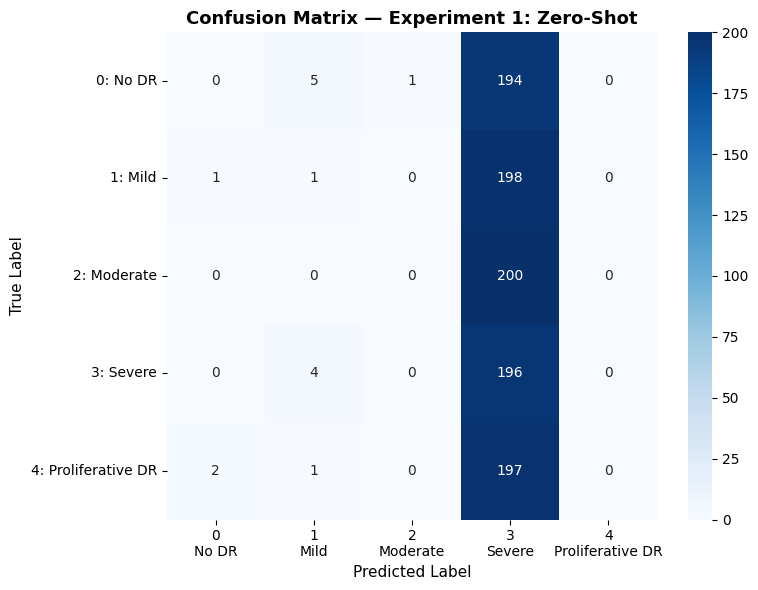

⏱️  Experiment 1 inference time: 5.06s

📝 Interpretation: Results above are the BASELINE.
   Any accuracy close to 20% (1/5 classes) suggests random guessing.
   Experiments 2 and 3 should significantly improve on this.


In [13]:
print('🧪 Experiment 1: Zero-Shot Evaluation (Pre-trained ResNet-50, no training)')
print('=' * 65)

# ── Load fresh model ──────────────────────────────────────────────────────────
model_exp1 = load_resnet50().to(DEVICE)

# Freeze ALL layers (no gradient computation during eval is sufficient,
# but we also freeze to make the intent explicit)
for param in model_exp1.parameters():
    param.requires_grad = False

n_params = sum(p.numel() for p in model_exp1.parameters())
print(f'   Total parameters    : {n_params:,}')
print(f'   Trainable parameters: 0 (all frozen)')
print()

# ── Run evaluation ────────────────────────────────────────────────────────────
t_exp1_start = time.time()
results_exp1 = evaluate_model(model_exp1, test_loader, 'Experiment 1: Zero-Shot')
t_exp1 = time.time() - t_exp1_start

results_exp1['time'] = t_exp1
experiment_results['Exp 1: Zero-Shot'] = results_exp1

print(f'⏱️  Experiment 1 inference time: {t_exp1:.2f}s')
print()
print('📝 Interpretation: Results above are the BASELINE.')
print('   Any accuracy close to 20% (1/5 classes) suggests random guessing.')
print('   Experiments 2 and 3 should significantly improve on this.')

---
## Section 10: Experiment 2 — Fine-Tune Last FC Layer Only

**Objective:** Freeze all convolutional layers of ResNet-50 (preserving ImageNet features) and train **only the new 5-class FC head**. This is the standard "feature extraction" transfer learning approach.

**Strategy:**
- All ResNet-50 convolutional blocks → frozen (`requires_grad = False`)
- Custom FC head → trainable (`requires_grad = True`)

**Benefits:**
- Fast training (only the head has gradients)
- Low risk of losing useful pre-trained features
- Good starting point for further fine-tuning in Experiment 3

The model is saved to Google Drive after training. Training loss and accuracy are plotted per epoch.

🎯 Experiment 2: Fine-Tune Last FC Layer Only
   Total parameters    : 24,560,709
   Trainable parameters: 1,052,677 (FC head only)
   Frozen parameters   : 23,508,032

   Optimizer : Adam (lr=0.0001)
   Loss      : CrossEntropyLoss
   Epochs    : 10

  [Experiment 2] Epoch  1/10  Loss: 1.0394  Acc: 57.25%  (20s elapsed)
  [Experiment 2] Epoch  2/10  Loss: 0.7972  Acc: 69.65%  (39s elapsed)
  [Experiment 2] Epoch  3/10  Loss: 0.7274  Acc: 72.45%  (58s elapsed)
  [Experiment 2] Epoch  4/10  Loss: 0.6611  Acc: 75.45%  (77s elapsed)
  [Experiment 2] Epoch  5/10  Loss: 0.6260  Acc: 76.58%  (97s elapsed)
  [Experiment 2] Epoch  6/10  Loss: 0.5923  Acc: 78.25%  (117s elapsed)
  [Experiment 2] Epoch  7/10  Loss: 0.5676  Acc: 79.07%  (135s elapsed)
  [Experiment 2] Epoch  8/10  Loss: 0.5321  Acc: 80.27%  (156s elapsed)
  [Experiment 2] Epoch  9/10  Loss: 0.5054  Acc: 81.77%  (175s elapsed)
  [Experiment 2] Epoch 10/10  Loss: 0.4979  Acc: 81.97%  (194s elapsed)

⏱️  Training time: 194.32s (3.2 m

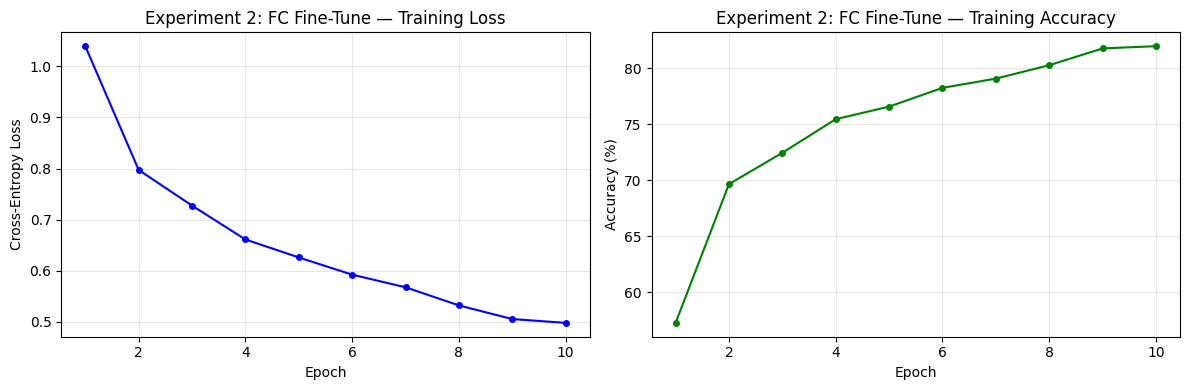


📊 Experiment 2: FC Fine-Tune — Test Set Results
═══════════════════════════════════════════════════════
  Overall Accuracy :  79.80%
  Macro Precision  :  80.21%
  Macro Recall     :  79.80%
  Macro F1-Score   :  79.54%

                      precision    recall  f1-score   support

           No DR (0)       0.92      0.96      0.94       200
            Mild (1)       0.72      0.85      0.78       200
        Moderate (2)       0.73      0.77      0.74       200
          Severe (3)       0.83      0.80      0.82       200
Proliferative DR (4)       0.82      0.60      0.70       200

            accuracy                           0.80      1000
           macro avg       0.80      0.80      0.80      1000
        weighted avg       0.80      0.80      0.80      1000



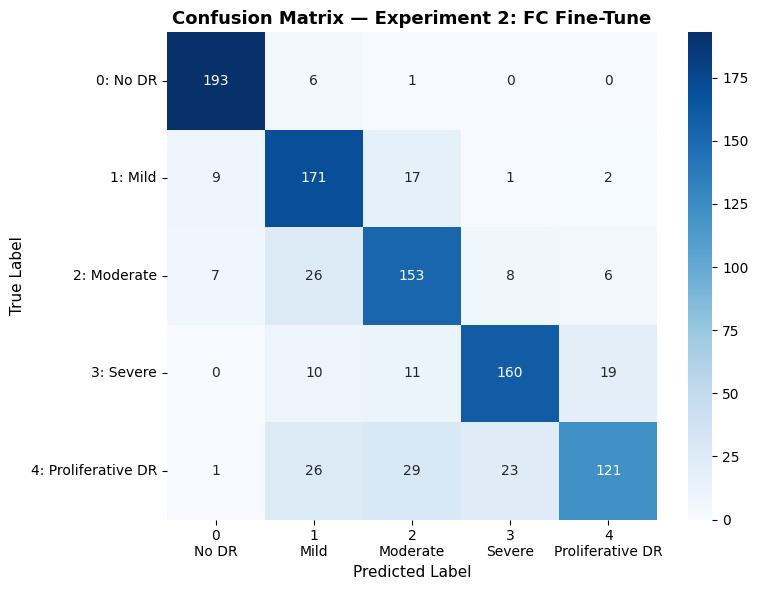


💾 Model saved to: /content/drive/MyDrive/Diabetic_Retinopathy/models/exp2_fc_finetune.pth (107.0 MB)


In [14]:
print('🎯 Experiment 2: Fine-Tune Last FC Layer Only')
print('=' * 65)

# ── Load fresh model ──────────────────────────────────────────────────────────
model_exp2 = load_resnet50().to(DEVICE)

# ── Freeze ALL layers ─────────────────────────────────────────────────────────
for param in model_exp2.parameters():
    param.requires_grad = False

# ── Unfreeze ONLY the FC head ─────────────────────────────────────────────────
for param in model_exp2.fc.parameters():
    param.requires_grad = True

n_total     = sum(p.numel() for p in model_exp2.parameters())
n_trainable = sum(p.numel() for p in model_exp2.parameters() if p.requires_grad)
print(f'   Total parameters    : {n_total:,}')
print(f'   Trainable parameters: {n_trainable:,} (FC head only)')
print(f'   Frozen parameters   : {n_total - n_trainable:,}')
print()

# ── Optimizer & loss ─────────────────────────────────────────────────────────
optimizer_exp2 = optim.Adam(
    filter(lambda p: p.requires_grad, model_exp2.parameters()),
    lr=LEARNING_RATE
)
criterion = nn.CrossEntropyLoss()

print(f'   Optimizer : Adam (lr={LEARNING_RATE})')
print(f'   Loss      : CrossEntropyLoss')
print(f'   Epochs    : {NUM_EPOCHS}')
print()

# ── Train ─────────────────────────────────────────────────────────────────────
model_exp2, history_exp2, t_train_exp2 = train_model(
    model_exp2, optimizer_exp2, criterion, NUM_EPOCHS,
    'Experiment 2'
)

print(f'\n⏱️  Training time: {t_train_exp2:.2f}s ({t_train_exp2/60:.1f} min)')

# ── Plot training curves ─────────────────────────────────────────────────────
plot_training_history(history_exp2, 'Experiment 2: FC Fine-Tune')

# ── Evaluate ──────────────────────────────────────────────────────────────────
t_eval_start = time.time()
results_exp2 = evaluate_model(model_exp2, test_loader, 'Experiment 2: FC Fine-Tune')
t_eval_exp2 = time.time() - t_eval_start
results_exp2['time'] = t_train_exp2 + t_eval_exp2
experiment_results['Exp 2: FC Fine-Tune'] = results_exp2

# ── Save model to Google Drive ────────────────────────────────────────────────
save_path_exp2 = os.path.join(MODELS_DIR, 'exp2_fc_finetune.pth')
torch.save({
    'model_state_dict': model_exp2.state_dict(),
    'optimizer_state_dict': optimizer_exp2.state_dict(),
    'history': history_exp2,
    'results': {
        'accuracy': results_exp2['accuracy'],
        'macro_f1': results_exp2['macro_f1']
    },
    'config': {
        'USE_BATCH_NORM': USE_BATCH_NORM,
        'LEARNING_RATE': LEARNING_RATE,
        'NUM_EPOCHS': NUM_EPOCHS,
        'experiment': 'Experiment 2: FC Fine-Tune'
    }
}, save_path_exp2)

size_mb = os.path.getsize(save_path_exp2) / 1e6
print(f'\n💾 Model saved to: {save_path_exp2} ({size_mb:.1f} MB)')

---
## Section 11: Experiment 3 — Deep Layer Fine-Tuning

**Objective:** Unfreeze deeper convolutional blocks (configurable via `UNFREEZE_LAYERS`) in addition to the FC head. This allows the model to adapt its feature representations to the retinal image domain, potentially improving accuracy for subtle class distinctions.

**Strategy:**
- We start from the Experiment 2 model weights (warm start)
- Unfreeze: `layer4` (the deepest ResNet block) + `fc` head
- Use a **lower learning rate** (`LR_EXP3 = 1e-5`) to avoid catastrophic forgetting

**Considerations:**
- More parameters → longer training
- Risk of overfitting increases — monitor accuracy carefully
- Model is saved to Google Drive only if ≥500MB free space is available

ResNet-50 layer structure:
```
conv1 → bn1 → relu → maxpool → layer1 → layer2 → layer3 → layer4 → avgpool → fc
```

🚀 Experiment 3: Deep Layer Fine-Tuning
   Layers to unfreeze: ['layer4', 'fc']
   Starting from     : Experiment 2 model weights
   Learning rate     : 1e-05 (reduced to prevent catastrophic forgetting)

   ✅ Unfroze: layer4
   ✅ Unfroze: fc

   Total parameters    : 24,560,709
   Trainable parameters: 16,017,413
   Frozen parameters   : 8,543,296

  [Experiment 3] Epoch  1/10  Loss: 0.4622  Acc: 82.80%  (22s elapsed)
  [Experiment 3] Epoch  2/10  Loss: 0.3914  Acc: 86.33%  (44s elapsed)
  [Experiment 3] Epoch  3/10  Loss: 0.3337  Acc: 89.80%  (68s elapsed)
  [Experiment 3] Epoch  4/10  Loss: 0.2857  Acc: 91.85%  (91s elapsed)
  [Experiment 3] Epoch  5/10  Loss: 0.2436  Acc: 93.65%  (114s elapsed)
  [Experiment 3] Epoch  6/10  Loss: 0.1966  Acc: 95.67%  (137s elapsed)
  [Experiment 3] Epoch  7/10  Loss: 0.1806  Acc: 95.17%  (159s elapsed)
  [Experiment 3] Epoch  8/10  Loss: 0.1679  Acc: 96.00%  (183s elapsed)
  [Experiment 3] Epoch  9/10  Loss: 0.1380  Acc: 96.73%  (206s elapsed)
  [Ex

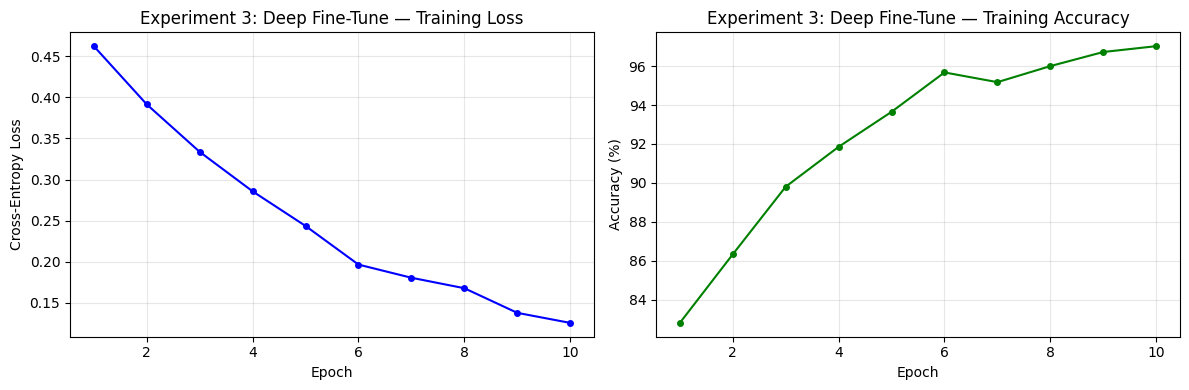


📊 Experiment 3: Deep Fine-Tune — Test Set Results
═══════════════════════════════════════════════════════
  Overall Accuracy :  85.70%
  Macro Precision  :  85.77%
  Macro Recall     :  85.70%
  Macro F1-Score   :  85.65%

                      precision    recall  f1-score   support

           No DR (0)       0.95      0.97      0.96       200
            Mild (1)       0.84      0.86      0.85       200
        Moderate (2)       0.77      0.81      0.79       200
          Severe (3)       0.87      0.88      0.87       200
Proliferative DR (4)       0.86      0.76      0.81       200

            accuracy                           0.86      1000
           macro avg       0.86      0.86      0.86      1000
        weighted avg       0.86      0.86      0.86      1000



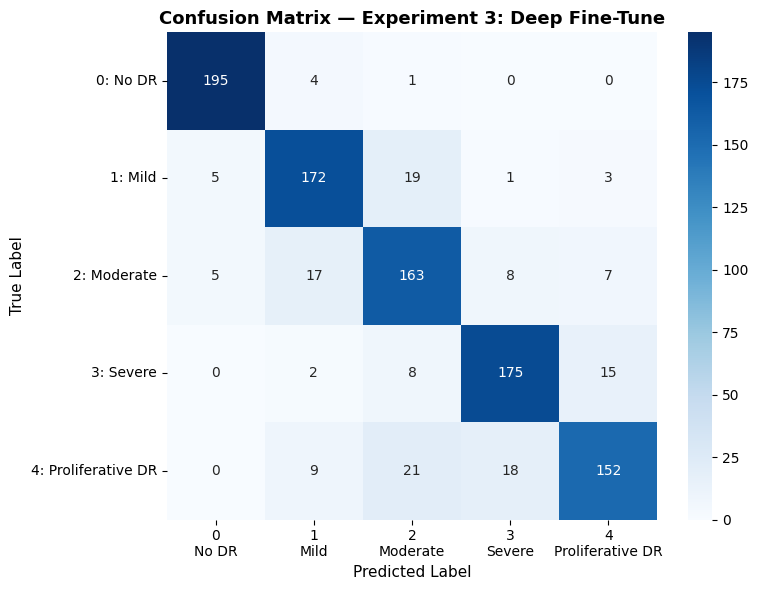


💾 Google Drive free space: 6542 MB
✅ Model saved: /content/drive/MyDrive/Diabetic_Retinopathy/models/exp3_deep_finetune.pth (226.7 MB)


In [15]:
print('🚀 Experiment 3: Deep Layer Fine-Tuning')
print('=' * 65)
print(f'   Layers to unfreeze: {UNFREEZE_LAYERS}')
print(f'   Starting from     : Experiment 2 model weights')
print(f'   Learning rate     : {LR_EXP3} (reduced to prevent catastrophic forgetting)')
print()

# ── Start from Experiment 2 weights ──────────────────────────────────────────
model_exp3 = copy.deepcopy(model_exp2)

# ── Freeze everything ─────────────────────────────────────────────────────────
for param in model_exp3.parameters():
    param.requires_grad = False

# ── Unfreeze the specified layers ─────────────────────────────────────────────
for layer_name in UNFREEZE_LAYERS:
    if hasattr(model_exp3, layer_name):
        layer = getattr(model_exp3, layer_name)
        for param in layer.parameters():
            param.requires_grad = True
        print(f'   ✅ Unfroze: {layer_name}')
    else:
        print(f'   ⚠️  Layer not found: {layer_name} (skipped)')

n_total     = sum(p.numel() for p in model_exp3.parameters())
n_trainable = sum(p.numel() for p in model_exp3.parameters() if p.requires_grad)
print(f'\n   Total parameters    : {n_total:,}')
print(f'   Trainable parameters: {n_trainable:,}')
print(f'   Frozen parameters   : {n_total - n_trainable:,}')
print()

# ── Optimizer & loss ─────────────────────────────────────────────────────────
optimizer_exp3 = optim.Adam(
    filter(lambda p: p.requires_grad, model_exp3.parameters()),
    lr=LR_EXP3
)
criterion = nn.CrossEntropyLoss()

# ── Train ─────────────────────────────────────────────────────────────────────
model_exp3, history_exp3, t_train_exp3 = train_model(
    model_exp3, optimizer_exp3, criterion, NUM_EPOCHS,
    'Experiment 3'
)

print(f'\n⏱️  Training time: {t_train_exp3:.2f}s ({t_train_exp3/60:.1f} min)')

# ── Plot training curves ─────────────────────────────────────────────────────
plot_training_history(history_exp3, 'Experiment 3: Deep Fine-Tune')

# ── Evaluate ──────────────────────────────────────────────────────────────────
t_eval_start = time.time()
results_exp3 = evaluate_model(model_exp3, test_loader, 'Experiment 3: Deep Fine-Tune')
t_eval_exp3 = time.time() - t_eval_start
results_exp3['time'] = t_train_exp3 + t_eval_exp3
experiment_results['Exp 3: Deep Fine-Tune'] = results_exp3

# ── Save model (only if sufficient space) ─────────────────────────────────────
MIN_FREE_SPACE_MB = 500

def get_free_space_mb(path: str) -> float:
    stat = shutil.disk_usage(path)
    return stat.free / 1e6

free_mb = get_free_space_mb('/content/drive')
print(f'\n💾 Google Drive free space: {free_mb:.0f} MB')

if free_mb >= MIN_FREE_SPACE_MB:
    save_path_exp3 = os.path.join(MODELS_DIR, 'exp3_deep_finetune.pth')
    torch.save({
        'model_state_dict': model_exp3.state_dict(),
        'optimizer_state_dict': optimizer_exp3.state_dict(),
        'history': history_exp3,
        'results': {
            'accuracy': results_exp3['accuracy'],
            'macro_f1': results_exp3['macro_f1']
        },
        'config': {
            'USE_BATCH_NORM': USE_BATCH_NORM,
            'LR_EXP3': LR_EXP3,
            'NUM_EPOCHS': NUM_EPOCHS,
            'UNFREEZE_LAYERS': UNFREEZE_LAYERS,
            'experiment': 'Experiment 3: Deep Fine-Tune'
        }
    }, save_path_exp3)
    size_mb = os.path.getsize(save_path_exp3) / 1e6
    print(f'✅ Model saved: {save_path_exp3} ({size_mb:.1f} MB)')
else:
    print(f'⚠️  Insufficient space ({free_mb:.0f} MB < {MIN_FREE_SPACE_MB} MB).')
    print('   Experiment 3 model NOT saved to Drive.')
    print('   Free up space in your Google Drive and re-run this cell to save.')

---
## Section 12: Results Comparison Across All Experiments

This final section consolidates results from all three experiments into a comprehensive comparison. We display:

1. **Side-by-side summary table** — accuracy, macro F1, precision, recall, and training time for each experiment
2. **Bar chart comparison** — visual comparison of accuracy and macro F1 across experiments
3. **Timing breakdown** — complete breakdown of all timed pipeline stages
4. **Key findings** — brief interpretation of the results

This gives you a complete picture of how each training strategy affected model performance.

📊 Final Results Comparison

📋 Performance Summary Table:


,Accuracy (%),Macro F1 (%),Macro Precision (%),Macro Recall (%),Time (s)
Experiment,,,,,
Exp 1: Zero-Shot,19.70,6.81,5.80,19.70,5.1
Exp 2: FC Fine-Tune,79.80,79.54,80.21,79.80,199.5
Exp 3: Deep Fine-Tune,85.70,85.65,85.77,85.70,233.6


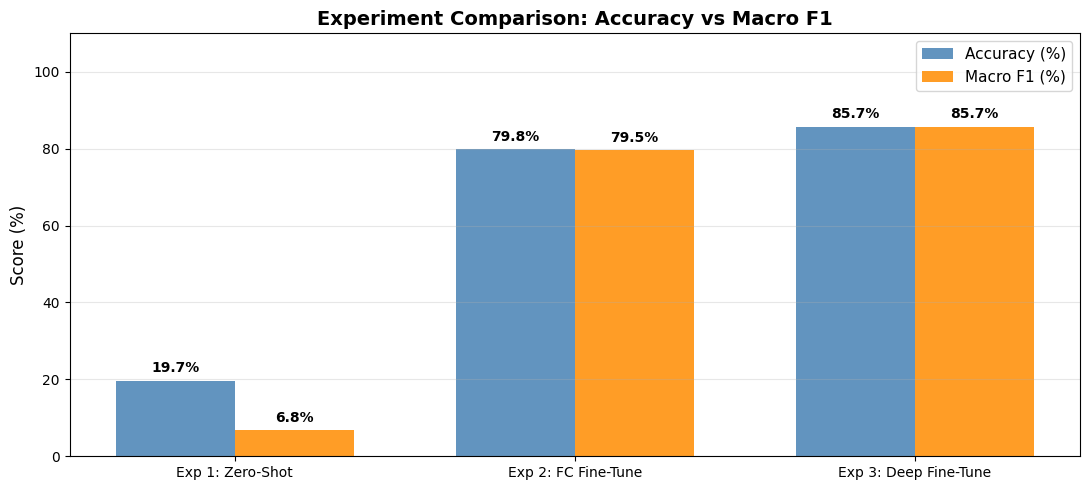


⏱️  Complete Pipeline Timing Breakdown:
--------------------------------------------------
  Balance Preprocessing              :      0.2s  (0.0 min)
  Resolution Preprocessing           :   3730.1s  (62.2 min)
  Dataset Split & DataLoaders        :      0.0s  (0.0 min)
  Exp 1: Zero-Shot Inference         :      5.1s  (0.1 min)
  Exp 2: FC Fine-Tune                :    199.5s  (3.3 min)
  Exp 3: Deep Fine-Tune              :    233.6s  (3.9 min)
--------------------------------------------------
  Total Pipeline Time                :   4168.4s  (69.5 min)

🔍 Key Findings:
  ✅ Best experiment by Macro F1: Exp 3: Deep Fine-Tune
     Best Accuracy  : 85.70%
     Best Macro F1  : 85.65%
  📈 Accuracy gain (Exp1 → Exp2): +60.10%
  📈 Accuracy change (Exp2 → Exp3): +5.90%

  Models saved at: /content/drive/MyDrive/Diabetic_Retinopathy/models

✅ Pipeline complete! 🎉


In [16]:
print('📊 Final Results Comparison')
print('=' * 70)

# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for exp_name, res in experiment_results.items():
    rows.append({
        'Experiment': exp_name,
        'Accuracy (%)': f"{res['accuracy']*100:.2f}",
        'Macro F1 (%)': f"{res['macro_f1']*100:.2f}",
        'Macro Precision (%)': f"{res['macro_precision']*100:.2f}",
        'Macro Recall (%)': f"{res['macro_recall']*100:.2f}",
        'Time (s)': f"{res['time']:.1f}"
    })

summary_df = pd.DataFrame(rows)
print('\n📋 Performance Summary Table:')
display(summary_df.set_index('Experiment'))

# ── Bar chart comparison ───────────────────────────────────────────────────────
exp_labels = list(experiment_results.keys())
accuracies = [experiment_results[k]['accuracy'] * 100 for k in exp_labels]
macro_f1s  = [experiment_results[k]['macro_f1']  * 100 for k in exp_labels]

x = np.arange(len(exp_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, accuracies, width,
               label='Accuracy (%)', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, macro_f1s,  width,
               label='Macro F1 (%)',  color='darkorange', alpha=0.85)

# Value labels on bars
for bar in bars1:
    ax.annotate(f'{bar.get_height():.1f}%',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.annotate(f'{bar.get_height():.1f}%',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(exp_labels, fontsize=10)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Experiment Comparison: Accuracy vs Macro F1',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Complete timing breakdown ──────────────────────────────────────────────────
print('\n⏱️  Complete Pipeline Timing Breakdown:')
print('-' * 50)
timing_rows = [
    ('Balance Preprocessing',     t_balance),
    ('Resolution Preprocessing',  t_resize),
    ('Dataset Split & DataLoaders', t_split),
    ('Exp 1: Zero-Shot Inference', experiment_results.get('Exp 1: Zero-Shot', {}).get('time', 0)),
    ('Exp 2: FC Fine-Tune',       experiment_results.get('Exp 2: FC Fine-Tune', {}).get('time', 0)),
    ('Exp 3: Deep Fine-Tune',     experiment_results.get('Exp 3: Deep Fine-Tune', {}).get('time', 0)),
]
total_pipeline_time = sum(t for _, t in timing_rows)
for stage, t in timing_rows:
    print(f'  {stage:<35}: {t:>8.1f}s  ({t/60:.1f} min)')
print('-' * 50)
print(f'  {"Total Pipeline Time":<35}: {total_pipeline_time:>8.1f}s  ({total_pipeline_time/60:.1f} min)')

# ── Key Findings ───────────────────────────────────────────────────────────────
print('\n🔍 Key Findings:')
best_exp = max(experiment_results.items(), key=lambda kv: kv[1]['macro_f1'])
exp1_acc = experiment_results.get('Exp 1: Zero-Shot', {}).get('accuracy', 0)
exp2_acc = experiment_results.get('Exp 2: FC Fine-Tune', {}).get('accuracy', 0)
exp3_acc = experiment_results.get('Exp 3: Deep Fine-Tune', {}).get('accuracy', 0)
print(f'  ✅ Best experiment by Macro F1: {best_exp[0]}')
print(f'     Best Accuracy  : {best_exp[1]["accuracy"]*100:.2f}%')
print(f'     Best Macro F1  : {best_exp[1]["macro_f1"]*100:.2f}%')
if exp2_acc > 0 and exp1_acc > 0:
    print(f'  📈 Accuracy gain (Exp1 → Exp2): +{(exp2_acc - exp1_acc)*100:.2f}%')
if exp3_acc > 0 and exp2_acc > 0:
    delta = (exp3_acc - exp2_acc) * 100
    arrow = '📈' if delta >= 0 else '📉'
    print(f'  {arrow} Accuracy change (Exp2 → Exp3): {delta:+.2f}%')
print(f'\n  Models saved at: {MODELS_DIR}')
print('\n✅ Pipeline complete! 🎉')